In [134]:
import pandas as pd
import numpy as np
import re 
import matplotlib.pyplot as plt
import unicodedata


In [135]:
df = pd.read_excel(r'/Users/nglongvu1002/Desktop/Business Insights and Reporting Specialist Role.xlsx')
df.head(20)

,city,state,postcode,country,can_contact,sold_date,event_date,event_desc,num_tickets
0,Sydney,NSW,2155.0,AU,N,2025-02-24,2025-04-12,Single Day Entry,2
1,Strathfield,NSW,2135.0,AU,N,2025-02-24,2025-04-12,Single Day Entry,4
2,Bondi,NSW,2026.0,AU,N,2025-02-24,2025-04-17,Single Day Entry,3
3,Penrith,NSW,2750.0,AU,N,2025-02-24,2025-04-12,Single Day Entry,2
4,Fairy Meadow,NSW,2519.0,AU,Y,2025-02-24,2025-04-16,Reserved Seating,4
5,Fairy Meadow,NSW,2519.0,AU,Y,2025-02-24,2025-04-16,Reserved Seating,1
6,Largs,NSW,2320.0,AU,N,2025-02-24,2025-04-12,Single Day Entry,8
7,Thornton,NSW,2322.0,AU,N,2025-02-24,2025-04-12,Single Day Entry,2
8,Abermain,NSW,2326.0,AU,Y,2025-02-24,2025-04-12,Single Day Entry,1
9,Abermain,NSW,2326.0,AU,Y,2025-02-24,2025-04-12,Single Day Entry,1


In [136]:
df.describe()

,postcode,sold_date,event_date,num_tickets
count,1942.000000,1999,1999,1999.000000
mean,3560.263131,2025-02-25 20:01:33.646823424,2025-04-14 22:29:14.077038592,2.642321
min,0.000000,2025-02-24 00:00:00,2025-04-11 00:00:00,1.000000
25%,2143.250000,2025-02-24 00:00:00,2025-04-12 00:00:00,1.000000
50%,2232.000000,2025-02-24 00:00:00,2025-04-14 00:00:00,2.000000
75%,2560.000000,2025-02-25 00:00:00,2025-04-18 00:00:00,3.000000
max,732572.000000,2025-04-10 00:00:00,2025-04-23 00:00:00,80.000000
std,25370.995524,NaN,NaN,5.268528


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   city         1944 non-null   object        
 1   state        1915 non-null   object        
 2   postcode     1942 non-null   float64       
 3   country      1943 non-null   object        
 4   can_contact  1999 non-null   object        
 5   sold_date    1999 non-null   datetime64[ns]
 6   event_date   1999 non-null   datetime64[ns]
 7   event_desc   1999 non-null   object        
 8   num_tickets  1999 non-null   int64         
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 140.7+ KB


In [138]:
df['city'].unique()

array(['Sydney', 'Strathfield', 'Bondi', 'Penrith', 'Fairy Meadow',
       'Largs', 'Thornton', 'Abermain', 'South Penrith', 'GYEONGGIDO',
       'Pymble', 'Bronte', 'Morisset', 'Manly', 'Oatley', 'Riverwood',
       'Singapore', 'Shellharbour', 'Berkshire Park', 'Marrickville',
       'Oran Park', 'Wollongong', 'west hoxton', 'New Lambton',
       'Bankstown', 'St clair', 'Holsworthy', 'Parramatta', 'City',
       'Mount Hawthorn', 'MUDGEE', nan, 'Mosman', 'Speers Point',
       'Jewells', 'Peakhurst', 'captains flat', 'Panania', 'Trundle',
       'HURSTVILLE', 'Broadwater, NSW, 2472', 'Canley vale',
       'North Bondi', 'Jesmond', 'COOMA', 'Macquarie Park', 'Goulburn',
       'Annandale', 'Kentlyn', 'Carlingford', 'Conder', 'Toronto',
       'Corrimal', 'Coatesville', 'Blackwall', 'Alexandra Hills',
       'South Turramurra', 'ALBION PARK RAIL', 'Rouse Hill', 'rutherford',
       'Moggill', 'Rosebery', 'Baulkham Hills', 'Springwood',
       'Leichhardt', 'Elderslie', 'Castlehill', '

In [139]:
df['state'].unique()

array(['NSW', nan, 'ACT', 'WA', 'QLD', 'TAS', 'VIC', 'SA', 'NT', 'IA'],
      dtype=object)

In [140]:
df['postcode'].unique()

array([  2155.,   2135.,   2026.,   2750.,   2519.,   2320.,   2322.,
         2326.,  15348.,   2073.,   2024.,   2264.,   2095.,   2223.,
         2210., 358719.,   2529.,   2765.,   2204.,   2570.,   2500.,
         2171.,   2305.,   2200.,   2759.,   2173.,   2153.,   2601.,
         6016.,   2850.,     nan,   2088.,   2284.,   2280.,   2623.,
         2213.,   2875.,   2220.,   2150.,   2472.,   2166.,   2299.,
         2630.,   2113.,   2580.,   2038.,   2560.,   2118.,   2906.,
         2283.,   2518.,    793.,   2256.,   4161.,   2074.,   2527.,
         4070.,   2018.,   2777.,   2040.,   2154.,   2232.,   2559.,
         2540.,   2756.,   2075.,   2606.,   2230.,   2228.,   2127.,
         2327.,   2046.,   2087.,   2112.,   2070.,   2077.,   2110.,
         2460.,   2770.,   2745.,   2298.,   2790.,   2774.,   2221.,
         2565.,   2049.,   2114.,   2022.,   2911.,   2281.,   2262.,
         2218.,   2304.,   2261.,   2564.,   2031.,   2323.,   2160.,
         7320.,   21

In [141]:
df['country'].unique()

array(['AU', 'KR', 'SG', nan, 'NZ', 'HK', 'GB', 'PH', 'US'], dtype=object)

In [142]:
df['can_contact'].unique()

array(['N', 'Y'], dtype=object)

In [143]:
df['sold_date'].unique()

<DatetimeArray>
['2025-02-24 00:00:00', '2025-02-25 00:00:00', '2025-02-26 00:00:00',
 '2025-02-27 00:00:00', '2025-02-28 00:00:00', '2025-03-01 00:00:00',
 '2025-03-02 00:00:00', '2025-03-03 00:00:00', '2025-03-04 00:00:00',
 '2025-03-05 00:00:00', '2025-03-06 00:00:00', '2025-03-07 00:00:00',
 '2025-03-08 00:00:00', '2025-03-09 00:00:00', '2025-03-10 00:00:00',
 '2025-03-11 00:00:00', '2025-03-12 00:00:00', '2025-03-13 00:00:00',
 '2025-03-14 00:00:00', '2025-03-15 00:00:00', '2025-03-16 00:00:00',
 '2025-03-17 00:00:00', '2025-03-18 00:00:00', '2025-04-10 00:00:00',
 '2025-04-01 00:00:00', '2025-04-02 00:00:00', '2025-04-03 00:00:00',
 '2025-04-04 00:00:00']
Length: 28, dtype: datetime64[ns]

In [144]:
df['event_date'].unique()

<DatetimeArray>
['2025-04-12 00:00:00', '2025-04-17 00:00:00', '2025-04-16 00:00:00',
 '2025-04-22 00:00:00', '2025-04-20 00:00:00', '2025-04-18 00:00:00',
 '2025-04-23 00:00:00', '2025-04-15 00:00:00', '2025-04-11 00:00:00',
 '2025-04-14 00:00:00', '2025-04-13 00:00:00', '2025-04-19 00:00:00',
 '2025-04-21 00:00:00']
Length: 13, dtype: datetime64[ns]

In [145]:
df['event_desc'].unique()

array(['Single Day Entry', 'Reserved Seating', 'After 4pm Entry',
       'Donation', 'Big Bush BBQ', 'Dino Adventures',
       'Bianco - The Viewing', 'Give & Gather Bag', 'Angus Steakhouse'],
      dtype=object)

In [146]:
df['num_tickets'].unique()  

array([ 2,  4,  3,  1,  8,  5, 80, 12,  6,  7,  9, 22, 20, 50, 14, 25])

In [147]:
# Check missing values
print(df.isnull().sum())
# Fix column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

city           55
state          84
postcode       57
country        56
can_contact     0
sold_date       0
event_date      0
event_desc      0
num_tickets     0
dtype: int64


In [148]:
price_map = {
    "Single Day Entry": 50,
    "Reserved Seating": 50,
    "After 4 PM Entry": 35,
    "Big Bush BBQ": 20,
    "Dino Adventures": 25,
    "Angus Steakhouse": 50,
    "Bianco – The Viewing": 25,
    "Give & Gather Bag": 15,
    "Donation": 10
}

# Add the new column directly to df
df["estimated_price"] = df["event_desc"].map(price_map)

# Display the first few rows
print(df.head(20))

             city state  postcode country can_contact  sold_date event_date  \
0          Sydney   NSW    2155.0      AU           N 2025-02-24 2025-04-12   
1     Strathfield   NSW    2135.0      AU           N 2025-02-24 2025-04-12   
2           Bondi   NSW    2026.0      AU           N 2025-02-24 2025-04-17   
3         Penrith   NSW    2750.0      AU           N 2025-02-24 2025-04-12   
4    Fairy Meadow   NSW    2519.0      AU           Y 2025-02-24 2025-04-16   
5    Fairy Meadow   NSW    2519.0      AU           Y 2025-02-24 2025-04-16   
6           Largs   NSW    2320.0      AU           N 2025-02-24 2025-04-12   
7        Thornton   NSW    2322.0      AU           N 2025-02-24 2025-04-12   
8        Abermain   NSW    2326.0      AU           Y 2025-02-24 2025-04-12   
9        Abermain   NSW    2326.0      AU           Y 2025-02-24 2025-04-12   
10       Abermain   NSW    2326.0      AU           Y 2025-02-24 2025-04-12   
11       Abermain   NSW    2326.0      AU           

In [149]:
#Keep uppercase for the first letter of country column
df['city'] = df['city'].str.strip().str.title()
# Remove everything after the first comma in the city column
df['city'] = df['city'].apply(lambda x: re.sub(r',.*', '', str(x)))

In [150]:
def derive_state_from_postcode(postcode):
    if pd.isna(postcode):
        return None
    try:
        postcode = int(postcode)
        if (1000 <= postcode <= 2599) or (2619 <= postcode <= 2899) or (2921 <= postcode <= 2999):
            return 'NSW'
        elif (200 <= postcode <= 299) or (2600 <= postcode <= 2618) or (2900 <= postcode <= 2920):
            return 'ACT'
        elif (3000 <= postcode <= 3999) or (8000 <= postcode <= 8999):
            return 'VIC'
        elif (4000 <= postcode <= 4999) or (9000 <= postcode <= 9999):
            return 'QLD'
        elif (5000 <= postcode <= 5799) or (5800 <= postcode <= 5999):
            return 'SA'
        elif (6000 <= postcode <= 6797) or (6800 <= postcode <= 6999):
            return 'WA'
        elif (7000 <= postcode <= 7799) or (7800 <= postcode <= 7999):
            return 'TAS'
        elif (800 <= postcode <= 999):
            return 'NT'
        else:
            return None
    except:
        return None

# Apply it to missing or invalid states only
df['state'] = df.apply(
    lambda row: derive_state_from_postcode(row['postcode']) if pd.isna(row['state']) else row['state'],
    axis=1
)

df['postcode'] = pd.to_numeric(df['postcode'], errors='coerce').astype('Int64')


In [151]:
print(df.isna().sum())   

city                 0
state               75
postcode            57
country             56
can_contact          0
sold_date            0
event_date           0
event_desc           0
num_tickets          0
estimated_price    109
dtype: int64


In [152]:
# Identify AU vs international
df['is_international'] = df['country'].ne('AU')

# For international records:
# - Keep postcode as string (foreign postcodes can have >4 digits or letters)
# - Leave state as NaN
# - Do NOT impute NSW or AU defaults
# - Optionally create a region label
df.loc[df['is_international'], 'state'] = pd.NA
df.loc[df['is_international'], 'region_category'] = 'International'

# For AU records:
df.loc[~df['is_international'], 'region_category'] = 'Australia'

# (Optional) Recast postcodes for international entries back to string, so you don't lose values like '15348'
df['postcode'] = df.apply(
    lambda r: str(r['postcode']) if r['is_international'] and pd.notna(r['postcode'])
    else r['postcode'],
    axis=1
)


In [153]:
df.head(20)

,city,state,postcode,country,can_contact,sold_date,event_date,event_desc,num_tickets,estimated_price,is_international,region_category
0,Sydney,NSW,2155,AU,N,2025-02-24,2025-04-12,Single Day Entry,2,50.0,False,Australia
1,Strathfield,NSW,2135,AU,N,2025-02-24,2025-04-12,Single Day Entry,4,50.0,False,Australia
2,Bondi,NSW,2026,AU,N,2025-02-24,2025-04-17,Single Day Entry,3,50.0,False,Australia
3,Penrith,NSW,2750,AU,N,2025-02-24,2025-04-12,Single Day Entry,2,50.0,False,Australia
4,Fairy Meadow,NSW,2519,AU,Y,2025-02-24,2025-04-16,Reserved Seating,4,50.0,False,Australia
5,Fairy Meadow,NSW,2519,AU,Y,2025-02-24,2025-04-16,Reserved Seating,1,50.0,False,Australia
6,Largs,NSW,2320,AU,N,2025-02-24,2025-04-12,Single Day Entry,8,50.0,False,Australia
7,Thornton,NSW,2322,AU,N,2025-02-24,2025-04-12,Single Day Entry,2,50.0,False,Australia
8,Abermain,NSW,2326,AU,Y,2025-02-24,2025-04-12,Single Day Entry,1,50.0,False,Australia
9,Abermain,NSW,2326,AU,Y,2025-02-24,2025-04-12,Single Day Entry,1,50.0,False,Australia


In [154]:
df.isnull().sum()

city                  0
state                85
postcode             57
country              56
can_contact           0
sold_date             0
event_date            0
event_desc            0
num_tickets           0
estimated_price     109
is_international      0
region_category       0
dtype: int64

In [155]:
# Basic summary
print(df.info())
print(df.describe(include='all'))

# Quick shape check
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   city              1999 non-null   object        
 1   state             1914 non-null   object        
 2   postcode          1942 non-null   object        
 3   country           1943 non-null   object        
 4   can_contact       1999 non-null   object        
 5   sold_date         1999 non-null   datetime64[ns]
 6   event_date        1999 non-null   datetime64[ns]
 7   event_desc        1999 non-null   object        
 8   num_tickets       1999 non-null   int64         
 9   estimated_price   1890 non-null   float64       
 10  is_international  1999 non-null   bool          
 11  region_category   1999 non-null   object        
dtypes: bool(1), datetime64[ns](2), float64(1), int64(1), object(7)
memory usage: 173.9+ KB
None
        city state  postcode country can

In [156]:
# Convert to datetime if not already
df['sold_date'] = pd.to_datetime(df['sold_date'])
df['event_date'] = pd.to_datetime(df['event_date'])

# Create new columns for exploration
df['sold_month'] = df['sold_date'].dt.to_period('M')
df['event_month'] = df['event_date'].dt.to_period('M')

# Sales trend
sales_by_month = df.groupby('sold_month')['num_tickets'].sum().reset_index()
print(sales_by_month)

  sold_month  num_tickets
0    2025-02         4978
1    2025-03          203
2    2025-04          101


In [157]:
# Event popularity
event_summary = df.groupby('event_desc')['num_tickets'].agg(['sum','mean','count']).reset_index()
event_summary = event_summary.sort_values(by='sum', ascending=False)
print(event_summary)

             event_desc   sum      mean  count
8      Single Day Entry  3961  2.766061   1432
7      Reserved Seating   761  2.348765    324
0       After 4pm Entry   216  2.138614    101
4       Dino Adventures   170  3.148148     54
3          Big Bush BBQ    96  3.200000     30
6     Give & Gather Bag    34  1.062500     32
5              Donation    17  1.545455     11
2  Bianco - The Viewing    14  1.750000      8
1      Angus Steakhouse    13  1.857143      7


In [158]:
# Top 10 cities
top_cities = df.groupby('city')['num_tickets'].sum().reset_index().sort_values(by='num_tickets', ascending=False).head(10)
print(top_cities)

# Ticket sales by state
tickets_by_state = df.groupby('state')['num_tickets'].sum().reset_index().sort_values(by='num_tickets', ascending=False)
print(tickets_by_state)

           city  num_tickets
664         nan         1079
574      Sydney          103
285  Hurstville           43
303  Kellyville           35
41   Bateau Bay           32
649  Wollongong           29
465   Oran Park           29
251  Greystanes           28
308  Kensington           28
476  Parramatta           27
  state  num_tickets
1   NSW         3898
3   QLD          102
0   ACT           61
6   VIC           24
5   TAS           15
7    WA           12
2    NT            8
4    SA            3


In [159]:
#Region sales
region_sales = df.groupby('region_category')['num_tickets'].sum().reset_index()
print(region_sales)

  region_category  num_tickets
0       Australia         4123
1   International         1159


In [160]:
# Days between sold date and event date
df['days_until_event'] = (df['event_date'] - df['sold_date']).dt.days
print(df['days_until_event'].describe())

count    1999.000000
mean       48.102551
std         8.089464
min         1.000000
25%        46.000000
50%        49.000000
75%        52.000000
max        58.000000
Name: days_until_event, dtype: float64


<ipython-input-161-56989295d139>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_sales, x='sold_month', y='num_tickets', palette='Blues_d')


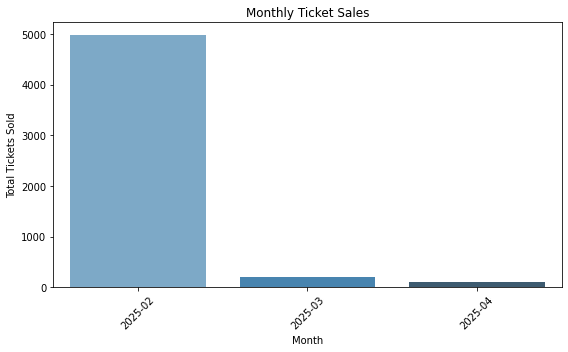

In [161]:
# Aggregate by month
monthly_sales = df.groupby('sold_month')['num_tickets'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=monthly_sales, x='sold_month', y='num_tickets', palette='Blues_d')
plt.title('Monthly Ticket Sales')
plt.xlabel('Month')
plt.ylabel('Total Tickets Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

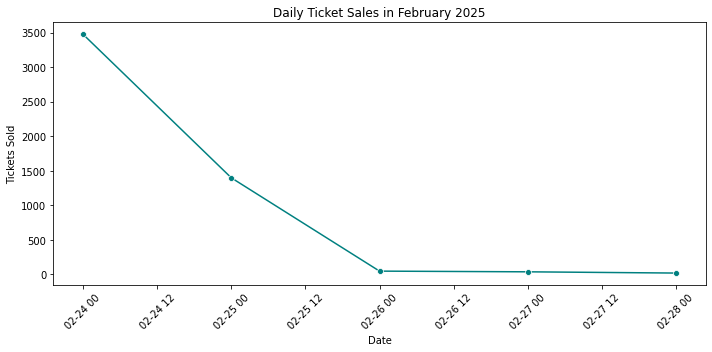

In [162]:
# Convert 'sold_date' to datetime if not already
df['sold_date'] = pd.to_datetime(df['sold_date'])

# Filter February 2025
february_df = df[df['sold_date'].dt.to_period('M') == '2025-02']

# Group by day
daily_sales = (february_df
               .groupby('sold_date')['num_tickets']
               .sum()
               .reset_index())

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=daily_sales, x='sold_date', y='num_tickets', marker='o', color='teal')
plt.title('Daily Ticket Sales in February 2025')
plt.xlabel('Date')
plt.ylabel('Tickets Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<ipython-input-163-fdbd76249216>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_summary, x='num_tickets', y='event_desc', palette='Blues_d')


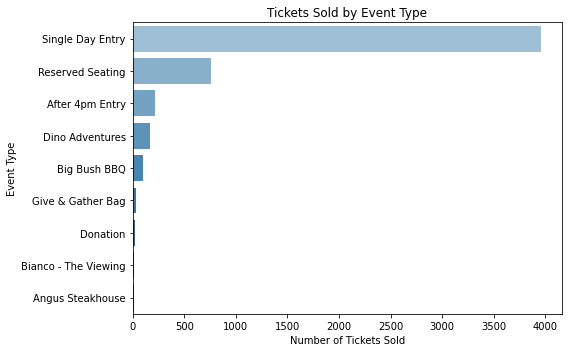

In [163]:
# Event type popularity
event_summary = df.groupby('event_desc')['num_tickets'].sum().reset_index().sort_values(by='num_tickets', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=event_summary, x='num_tickets', y='event_desc', palette='Blues_d')
plt.title('Tickets Sold by Event Type')
plt.xlabel('Number of Tickets Sold')
plt.ylabel('Event Type')
plt.tight_layout()
plt.show()

<ipython-input-164-93e740772356>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tickets_by_state, x='state', y='num_tickets', palette='viridis')


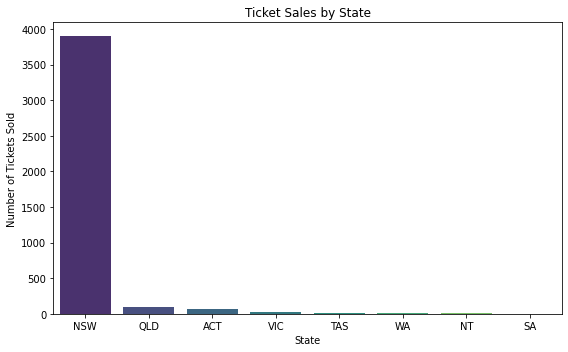

In [164]:
tickets_by_state = df.groupby('state')['num_tickets'].sum().reset_index().sort_values(by='num_tickets', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=tickets_by_state, x='state', y='num_tickets', palette='viridis')
plt.title('Ticket Sales by State')
plt.xlabel('State')
plt.ylabel('Number of Tickets Sold')
plt.tight_layout()
plt.show()

<ipython-input-165-a40114c5fbeb>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contact_pref, x='can_contact', y='num_tickets', palette='pastel')


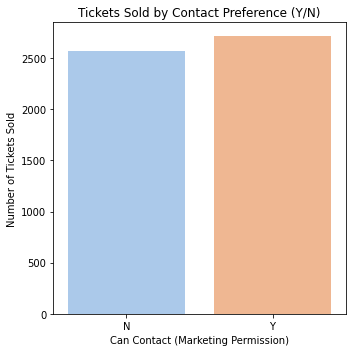

In [165]:
contact_pref = df.groupby('can_contact')['num_tickets'].sum().reset_index()

plt.figure(figsize=(5,5))
sns.barplot(data=contact_pref, x='can_contact', y='num_tickets', palette='pastel')
plt.title('Tickets Sold by Contact Preference (Y/N)')
plt.xlabel('Can Contact (Marketing Permission)')
plt.ylabel('Number of Tickets Sold')
plt.tight_layout()
plt.show()

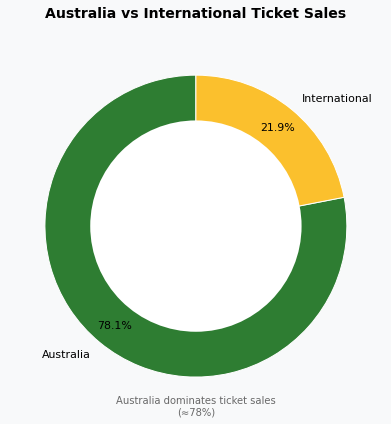

In [166]:
# Region sales pie chart
region_sales = (
    df.groupby('region_category')['num_tickets']
      .sum()
      .reset_index()
      .sort_values(by='num_tickets', ascending=False)
)

colors = ['#2E7D32', '#FBC02D']  
plt.figure(figsize=(6,6), facecolor='#f8f9fa')
wedges, texts, autotexts = plt.pie(
    region_sales['num_tickets'],
    labels=region_sales['region_category'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,  # move percentage text inside
    textprops={'color':'black', 'fontsize':11},
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

#  Add title and annotation
plt.title('Australia vs International Ticket Sales', fontsize=14, fontweight='bold', pad=20)
plt.text(0, -1.25, 'Australia dominates ticket sales\n(≈78%)', ha='center', fontsize=10, color='dimgray')
plt.tight_layout()
plt.show()


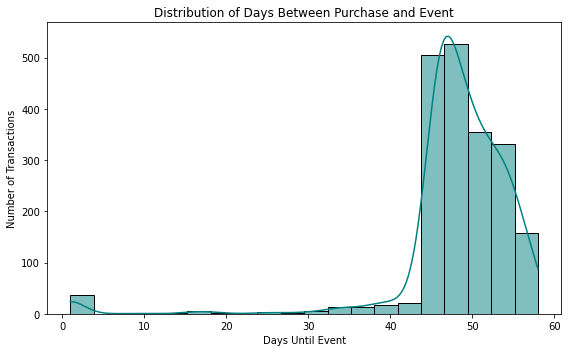

In [167]:
# Calculate days between sold_date and event_date
df['days_until_event'] = (df['event_date'] - df['sold_date']).dt.days
# Distribution between purchase and event date
plt.figure(figsize=(8,5))
sns.histplot(df['days_until_event'], bins=20, kde=True, color='teal')
plt.title('Distribution of Days Between Purchase and Event')
plt.xlabel('Days Until Event')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Lead-Time Insights (Days Between Purchase and Event)

| **Observation** | **Interpretation** | **Recommendation** |
|------------------|--------------------|--------------------|
| **Most purchases occur 40–55 days before the event** | Majority of customers plan early, showing structured purchasing behavior | Launch **early-bird campaigns** 6–8 weeks before event start |
| **Very few last-minute (0–10 day) purchases** | Limited impulse buying behavior | Introduce **last-minute deals** or **flash discounts** to capture spontaneous buyers |
| **Donation-based and premium events show slightly shorter lead times** | These are purpose-driven or exclusive purchases made closer to the event | Use **personalized reminders** or **limited-time upgrades** to drive urgency |
| **Consistent lead times across event types** | Stable purchase planning window across demographics | Align **marketing calendar** and **email sequences** with the ~6-week lead time trend |


<ipython-input-168-c8a93f774519>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='event_desc', y='days_until_event', palette='coolwarm')


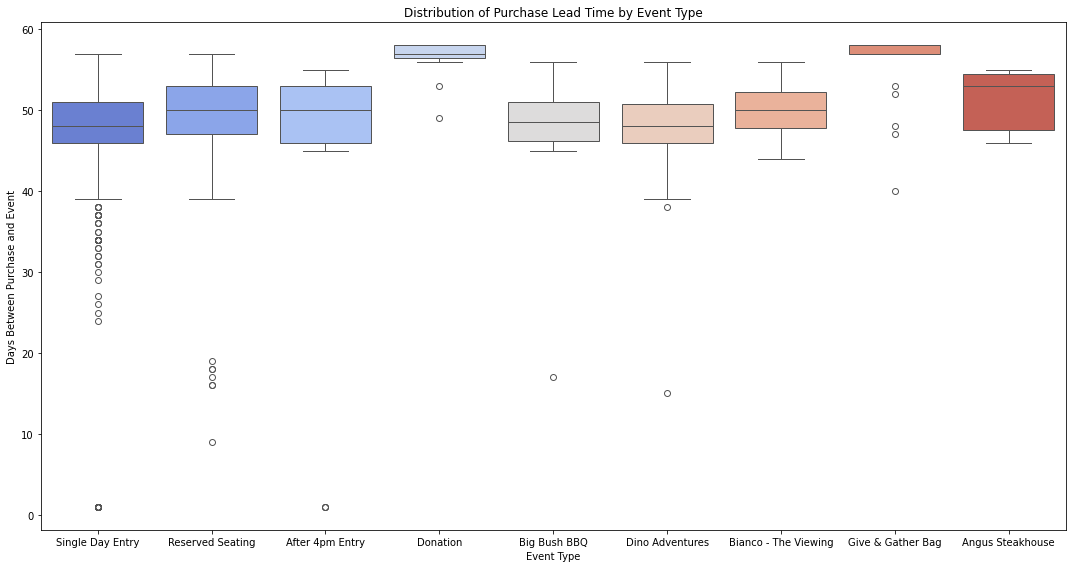

In [168]:
# Boxplot of days until event by event type
df['days_until_event'] = (df['event_date'] - df['sold_date']).dt.days
plt.figure(figsize=(15,8))
sns.boxplot(data=df, x='event_desc', y='days_until_event', palette='coolwarm')
plt.title('Distribution of Purchase Lead Time by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Days Between Purchase and Event')
plt.tight_layout()
plt.show()

### 🕒 Purchase Lead Time Analysis Summary

| **Aspect** | **Insight** |
|-------------|-------------|
| **Overall Finding** | Most customers purchase **6–8 weeks ahead of the event**, showing a predictable early booking pattern. |
| **Event Variations** | Core tickets like **Single Day Entry** and **Reserved Seating** show consistent advance purchases, while **Big Bush BBQ** and **Dino Adventures** tend to be booked closer to the event date. |
| **Premium Events** | Experiences such as **Angus Steakhouse** and **Give & Gather Bag** are booked earliest, indicating high exclusivity and early interest. |
| **Marketing Implication** | Launch **early marketing and limited-seating promotions** for premium events and maintain **steady communication** for regular ticket types. |
| **Strategic Recommendation** | Use this insight to **schedule campaign launches** by event category — targeting early planners for premium events and last-minute buyers for adventure or family-based experiences. |

<ipython-input-169-5d58d3304587>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cities, x='num_tickets', y='city', palette='viridis')


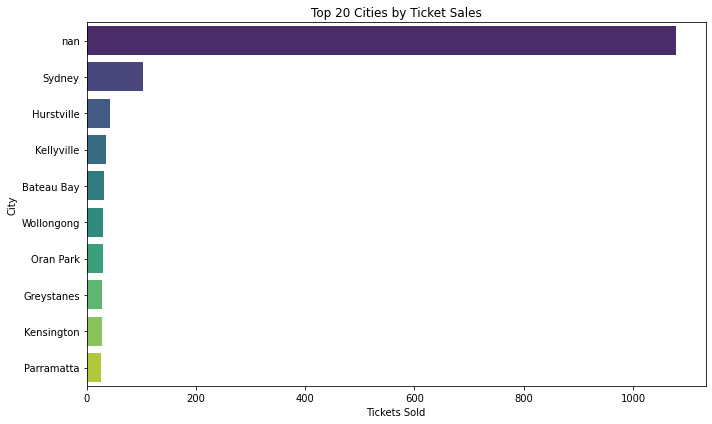

In [169]:
# Top 10 cities that has the most 
top_cities = (df.groupby('city')['num_tickets']
              .sum()
              .reset_index()
              .sort_values('num_tickets', ascending=False)
              .head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=top_cities, x='num_tickets', y='city', palette='viridis')
plt.title('Top 20 Cities by Ticket Sales')
plt.xlabel('Tickets Sold')
plt.ylabel('City')
plt.tight_layout()
plt.show()

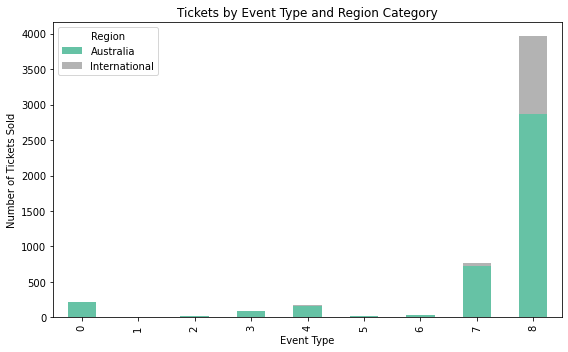

In [170]:
pivot = (df.pivot_table(index='event_desc', columns='region_category',
                        values='num_tickets', aggfunc='sum', fill_value=0)
          .reset_index())

pivot.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set2')
plt.title('Tickets by Event Type and Region Category')
plt.xlabel('Event Type')
plt.ylabel('Number of Tickets Sold')
plt.legend(title='Region')
plt.tight_layout()
plt.show()

In [171]:
# Group data by event and region
pivot = (
    df.pivot_table(
        index='event_desc',
        columns='region_category',
        values='num_tickets',
        aggfunc='sum',
        fill_value=0
    )
    .reset_index()
)

# Calculate total and percentage share
pivot['Total'] = pivot['Australia'] + pivot['International']
pivot['Australia_%'] = (pivot['Australia'] / pivot['Total'] * 100).round(1)
pivot['International_%'] = (pivot['International'] / pivot['Total'] * 100).round(1)

# Calculate percentage difference
pivot['% Difference (AU - INT)'] = (pivot['Australia_%'] - pivot['International_%']).round(1)

# Sort by dominance of Australia
pivot = pivot.sort_values('% Difference (AU - INT)', ascending=False)
pivot

region_category,event_desc,Australia,International,Total,Australia_%,International_%,% Difference (AU - INT)
1,Angus Steakhouse,13,0,13,100.0,0.0,100.0
2,Bianco - The Viewing,14,0,14,100.0,0.0,100.0
5,Donation,17,0,17,100.0,0.0,100.0
6,Give & Gather Bag,34,0,34,100.0,0.0,100.0
0,After 4pm Entry,212,4,216,98.1,1.9,96.2
3,Big Bush BBQ,94,2,96,97.9,2.1,95.8
7,Reserved Seating,721,40,761,94.7,5.3,89.4
4,Dino Adventures,156,14,170,91.8,8.2,83.6
8,Single Day Entry,2862,1099,3961,72.3,27.7,44.6


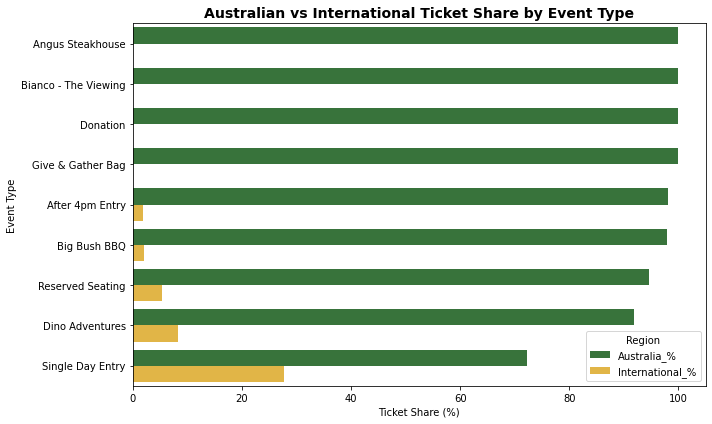

In [172]:
# Plot percentage comparison
plt.figure(figsize=(10,6))
pivot_melted = pivot.melt(
    id_vars='event_desc',
    value_vars=['Australia_%', 'International_%'],
    var_name='Region',
    value_name='Percentage'
)

sns.barplot(data=pivot_melted, x='Percentage', y='event_desc', hue='Region', palette=['#2E7D32', '#FBC02D'])
plt.title('Australian vs International Ticket Share by Event Type', fontsize=14, weight='bold')
plt.xlabel('Ticket Share (%)')
plt.ylabel('Event Type')
plt.legend(title='Region', loc='lower right')
plt.tight_layout()
plt.show()

### Regional Ticket Sales Insights (Australia vs International)

| **Observation** | **Interpretation** | **Recommendation** |
|------------------|--------------------|--------------------|
| **~78% of total tickets sold in Australia** | Domestic engagement dominates; events attract strong local participation | Maintain strong **local marketing campaigns** (e.g., NSW/VIC focus) and optimize **regional partnerships** |
| **~22% of tickets from international buyers** | Noticeable overseas interest, likely tourists or global followers | Develop **targeted international packages**, integrate **travel/event promotions** |
| **Certain event types (e.g., Bianco – The Viewing, Angus Steakhouse) show 100% Australian sales** | Niche or localized experiences | Focus **hyper-local advertising** and **community-based promotions** |
| **‘Single Day Entry’ and family events show higher international proportion (~30%)** | Popular among tourists visiting Sydney | Collaborate with **tourism boards** and **travel agencies** to expand international reach |


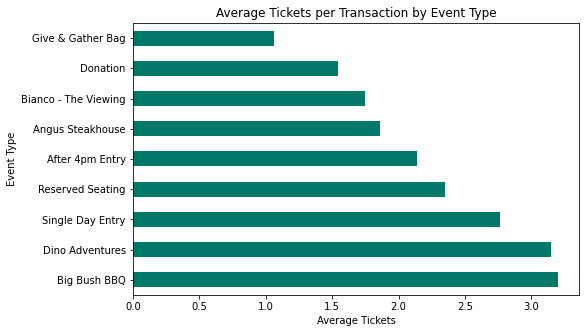

In [173]:
# Ticket average per transaction by event type
avg_tickets = df.groupby('event_desc')['num_tickets'].mean().sort_values(ascending=False)
avg_tickets.plot(kind='barh', color='#00796B', figsize=(8,5))
plt.title('Average Tickets per Transaction by Event Type')
plt.xlabel('Average Tickets')
plt.ylabel('Event Type')
plt.show()

###  Ticket Purchase Behavior Insights

| **Observation** | **Interpretation** | **Recommendation** |
|------------------|--------------------|--------------------|
| **High averages (3+) in family events** | Strong family/group attendance | Introduce **family bundle pricing** and **early-bird group offers** |
| **Mid averages (2–2.5) in general entry** | Small social groups | Target through **pair promotions** and **friends referral discounts** |
| **Low averages (< 1.5) in premium or donation events** | Individual participation | Promote **exclusive experiences** or **cause-driven storytelling** to boost engagement |


In [174]:
df

,city,state,postcode,country,can_contact,sold_date,event_date,event_desc,num_tickets,estimated_price,is_international,region_category,sold_month,event_month,days_until_event
0,Sydney,NSW,2155,AU,N,2025-02-24,2025-04-12,Single Day Entry,2,50.0,False,Australia,2025-02,2025-04,47
1,Strathfield,NSW,2135,AU,N,2025-02-24,2025-04-12,Single Day Entry,4,50.0,False,Australia,2025-02,2025-04,47
2,Bondi,NSW,2026,AU,N,2025-02-24,2025-04-17,Single Day Entry,3,50.0,False,Australia,2025-02,2025-04,52
3,Penrith,NSW,2750,AU,N,2025-02-24,2025-04-12,Single Day Entry,2,50.0,False,Australia,2025-02,2025-04,47
4,Fairy Meadow,NSW,2519,AU,Y,2025-02-24,2025-04-16,Reserved Seating,4,50.0,False,Australia,2025-02,2025-04,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,Camberwell,VIC,3124,AU,Y,2025-02-25,2025-04-19,Reserved Seating,2,50.0,False,Australia,2025-02,2025-04,53
1995,Camberwell,VIC,3124,AU,Y,2025-02-25,2025-04-19,Reserved Seating,1,50.0,False,Australia,2025-02,2025-04,53
1996,Yowie Bay,NSW,2228,AU,Y,2025-02-25,2025-04-23,Give & Gather Bag,1,15.0,False,Australia,2025-02,2025-04,57
1997,Yowie Bay,NSW,2228,AU,Y,2025-02-25,2025-04-20,Reserved Seating,4,50.0,False,Australia,2025-02,2025-04,54


In [175]:
df_cleaned = '/Users/nglongvu1002/Desktop/cleaned_RASNSW_dataset.csv'
df.to_csv(df_cleaned, index=False, encoding='utf-8-sig')
